In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
import itertools

#Creación

In [ ]:
np.random.seed(42)

# Cantidad de muestras
n_samples = 500

# Parámetros usados al generar los datos
loc = 50
scale = 10

# Generamos datos normales
data = np.random.normal(loc=loc, scale=scale, size=(n_samples, 5))

# Insertamos outliers en algunas filas (por ejemplo, en el 10%)
n_outliers = int(0.2 * n_samples)
outlier_indices = np.random.choice(n_samples, n_outliers, replace=False)

# Añadimos outliers proporcionales al loc y scale
for idx in outlier_indices:
    col = np.random.randint(0, 5)
    data[idx, col] = np.random.choice([
        np.random.uniform(loc + 4 * scale, loc + 6 * scale),  # outlier alto
        np.random.uniform(loc - 6 * scale, loc - 4 * scale)   # outlier bajo
    ])

# Creamos el DataFrame
columns = [f'feature_{i+1}' for i in range(5)]
df = pd.DataFrame(data, columns=columns)

# Añadimos la columna 'is_outlier'
df['is_outlier'] = 0
df.loc[outlier_indices, 'is_outlier'] = 1

df = df.drop_duplicates()

# Mostramos algunas filas
print(df.head(10))


   feature_1  feature_2  feature_3  feature_4  feature_5  is_outlier
0  54.967142  48.617357  56.476885  65.230299  47.658466           0
1  47.658630  65.792128  57.674347  45.305256  55.425600           0
2  45.365823  45.342702  52.419623  30.867198  32.750822           0
3  44.377125  39.871689  53.142473  40.919759  35.876963           0
4  64.656488  47.742237  50.675282  35.752518  44.556173           0
5  51.109226  38.490064  53.756980  43.993613  47.083063           0
6  43.982934  68.522782  49.865028  39.422891  58.225449           0
7  37.791564  52.088636  30.403299  36.718140  51.968612           0
8  96.720141  51.713683  48.843517  46.988963  35.214780           1
9  42.801558  45.393612   1.417548  53.436183  32.369598           1


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def pca_and_plot(X, y, n_components=2, figura_x=8, figura_y=6):
    """
    Función para aplicar PCA, reducir la dimensionalidad y graficar los resultados.

    Parameters:
    df (pd.DataFrame): El DataFrame con los datos.
    target_column (str): Nombre de la columna objetivo (por defecto 'is_outlier').
    n_components (int): Número de componentes principales para PCA (por defecto 2).
    figura_x (int): Ancho de la figura del gráfico.
    figura_y (int): Alto de la figura del gráfico.

    Returns:
    fig: Figura generada con el gráfico.
    pca_df: DataFrame con las dos componentes principales.
    """

    # Normalizar los datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Aplicar PCA
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(X_scaled)

    # Crear un DataFrame con las componentes principales, y usar el índice de X
    pca_df = pd.DataFrame(data=pca_result, columns=[f'PCA {i+1}' for i in range(n_components)], index=X.index)

    # Graficar los resultados
    fig, ax = plt.subplots(figsize=(figura_x, figura_y))

    y = y.loc[pca_df.index]  # Asegura que y tenga el mismo índice que pca_df

    # Filtrar los datos para los dos grupos
    normal_data = pca_df[y == 0]  # Datos normales
    outlier_data = pca_df[y == 1]  # Outliers

    # Graficar los dos grupos con colores diferentes
    ax.scatter(normal_data['PCA 1'], normal_data['PCA 2'], c='#1f77b4', label='Datos normales')
    ax.scatter(outlier_data['PCA 1'], outlier_data['PCA 2'], c='#d62728', label='Outliers', alpha=0.8)

    # Títulos y etiquetas
    ax.set_title('PCA - Reducción de Dimensionalidad')
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')
    ax.legend()

    plt.grid(True)

    return fig, pca_df

In [ ]:
def graficos(nombre, pca_df, y, outliers_results):
# Filtrar los datos para los dos grupos

    # Reset index before accessing by index
  pca_df = pca_df.reset_index(drop=True)
  outliers_results = outliers_results.reset_index(drop=True)
  y = y.reset_index(drop=True) # Reset index of y as well

  normal_data = pca_df[y == 0]  # Asumiendo que los datos normales son 0 en 'y'
  outlier_data = pca_df[y == 1]  # Asumiendo que los outliers son 1 en 'y'

  # Crear una figura con 4 subplots (2 filas x 2 columnas)
  fig, axes = plt.subplots(2, 2, figsize=(12, 10))
  fig.suptitle(f'Comparación de base vs métricas de {nombre}')

  # Scatter plot 1: base vs accuracy
  axes[0, 0].scatter(normal_data['PCA 1'], normal_data['PCA 2'], c='#1f77b4', label='Datos normales')
  axes[0, 0].scatter(outlier_data['PCA 1'], outlier_data['PCA 2'], c='#d62728', label='True outliers')
  outlier_indices = outliers_results[outliers_results[f"{nombre}_accuracy"] == True].index
  axes[0, 0].scatter(pca_df.iloc[outlier_indices, 0], pca_df.iloc[outlier_indices, 1], c='#ff7f0e', label='Outliers', marker='x')
  axes[0, 0].set_title('Base vs Accuracy')

  # Scatter plot 2: base vs recall
  axes[0, 1].scatter(normal_data['PCA 1'], normal_data['PCA 2'], c='#1f77b4', label='Datos normales')
  axes[0, 1].scatter(outlier_data['PCA 1'], outlier_data['PCA 2'], c='#d62728', label='True outliers')
  outlier_indices = outliers_results[outliers_results[f"{nombre}_recall"] == True].index
  axes[0, 1].scatter(pca_df.iloc[outlier_indices, 0], pca_df.iloc[outlier_indices, 1], color='#ff7f0e', label='Outliers', marker='x')
  axes[0, 1].set_title('Base vs Recall')

  # Scatter plot 3: base vs precision
  axes[1, 0].scatter(normal_data['PCA 1'], normal_data['PCA 2'], c='#1f77b4', label='Datos normales')
  axes[1, 0].scatter(outlier_data['PCA 1'], outlier_data['PCA 2'], c='#d62728', label='True outliers')
  outlier_indices = outliers_results[outliers_results[f"{nombre}_precision"] == True].index
  axes[1, 0].scatter(pca_df.iloc[outlier_indices, 0], pca_df.iloc[outlier_indices, 1], color='#ff7f0e', label='Outliers', marker='x')
  axes[1, 0].set_title('Base vs Precision')

  # Scatter plot 4: base vs f1
  axes[1, 1].scatter(normal_data['PCA 1'], normal_data['PCA 2'], c='#1f77b4', label='Datos normales')
  axes[1, 1].scatter(outlier_data['PCA 1'], outlier_data['PCA 2'], c='#d62728', label='True outliers')
  outlier_indices = outliers_results[outliers_results[f"{nombre}_f1"] == True].index
  axes[1, 1].scatter(pca_df.iloc[outlier_indices, 0], pca_df.iloc[outlier_indices, 1], color='#ff7f0e', label='Outliers', marker='x')
  axes[1, 1].set_title('Base vs F1 Score')

  # Ajustar el espacio entre subplots
  plt.tight_layout()
  plt.show()

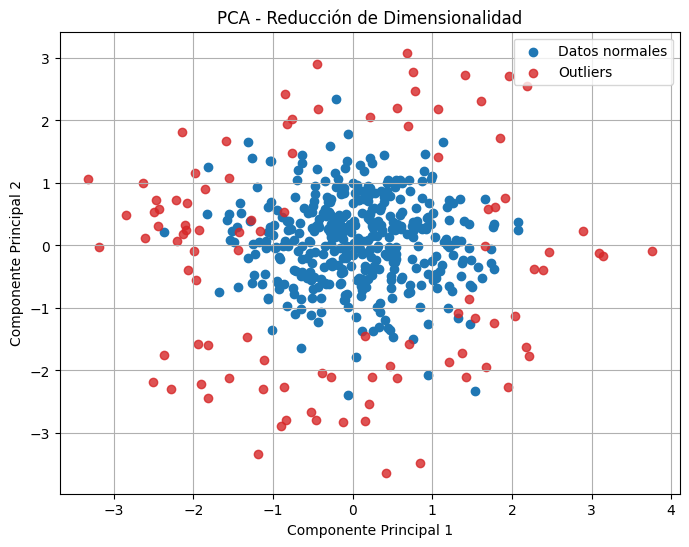

In [ ]:
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df.drop(columns=['is_outlier']), df['is_outlier'])

# Mostrar la figura
plt.show()

#Detección

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_multiple_confusion_matrices(y_trues_preds, titles, class_names=['Falso', 'Verdadero']):
    """
    y_trues_preds: lista de tuplas (y_true, y_pred)
    titles: lista de títulos para cada matriz
    class_names: etiquetas de las clases
    """

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Múltiples Matrices de Confusión')

    for idx, ((y_true, y_pred), title) in enumerate(zip(y_trues_preds, titles)):

        # Imprimir el classification_report (opcional)
        print(f"--- {title} ---")
        print(classification_report(y_true, y_pred, target_names=class_names))

        cm = confusion_matrix(y_true, y_pred)
        row, col = divmod(idx, 2)
        ax = axes[row, col]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [ ]:
from sklearn.cluster import KMeans

  # Función para actualizar los mejores resultados
def update_best_scores(best, best_n, best_metric, best_contamination, n_outliers, model, metric, score, n, samples, contamination, outliers, outliers_results):
  if score > best[metric]:
      best[metric] = score
      best_n[metric] = n
      best_metric[metric] = samples
      best_contamination[metric] = contamination
      outliers_results[f'{model}_{metric}'] = outliers
      n_outliers[metric] = outliers.sum()

def algoritmo(df):
  X = df.drop(columns=['is_outlier'])
  y = df['is_outlier']
  outliers_results = pd.DataFrame()
  outliers_results['base'] = df['is_outlier']

  # Rango de valores para los parámetros de K-Means
  n_clusters_values = [3, 5, 7, 10]  # Número de clusters
  init_values = ['k-means++', 'random']  # Métodos de inicialización
  threshold_values = np.linspace(70, 99, 5)  # Percentiles para el umbral de anomalía

  # Generar todas las combinaciones posibles
  combinaciones = itertools.product(n_clusters_values, init_values, threshold_values)



  # Diccionarios para almacenar los mejores resultados
  best = {'accuracy': -float('inf'), 'recall': -float('inf'),
              'precision': -float('inf'), 'f1': -float('inf')}
  best_n = {'accuracy': 0, 'recall': 0, 'precision': 0, 'f1': 0}
  best_metric = {'accuracy': 0, 'recall': 0, 'precision': 0, 'f1': 0}
  best_contamination = {'accuracy': 0, 'recall': 0, 'precision': 0, 'f1': 0}
  n_outliers = {'accuracy': 0, 'recall': 0, 'precision': 0, 'f1': 0}
  # Realizar el grid search
  for n_clusters, init, threshold in combinaciones:
      # Aplicar K-Means
      kmeans = KMeans(n_clusters=n_clusters, init=init, random_state=42)
      kmeans.fit(X)

      # Calcular distancias a los centroides
      distances = kmeans.transform(X)  # Distancia de cada punto a cada centroide
      min_distances = np.min(distances, axis=1)  # Distancia al centroide más cercano

      # Definir el umbral de anomalía basado en el percentil
      threshold_value = np.percentile(min_distances, threshold)
      outliers = min_distances > threshold_value  # True si es anomalía


      # Calcular las métricas
      current_accuracy = accuracy_score(y_true=y, y_pred=outliers)
      current_recall = recall_score(y_true=y, y_pred=outliers, zero_division=0)
      current_precision = precision_score(y_true=y, y_pred=outliers, zero_division=0)
      current_f1 = f1_score(y_true=y, y_pred=outliers, zero_division=0)

      # Actualizar los mejores resultados
      update_best_scores(best, best_n, best_metric, best_contamination, n_outliers, 'k-medias', 'accuracy', current_accuracy, n_clusters, init, threshold, outliers, outliers_results)
      update_best_scores(best, best_n, best_metric, best_contamination, n_outliers, 'k-medias', 'recall', current_recall, n_clusters, init, threshold, outliers, outliers_results)
      update_best_scores(best, best_n, best_metric, best_contamination, n_outliers, 'k-medias', 'precision', current_precision, n_clusters, init, threshold, outliers, outliers_results)
      update_best_scores(best, best_n, best_metric, best_contamination, n_outliers, 'k-medias', 'f1', current_f1, n_clusters, init, threshold, outliers, outliers_results)

  # Crear DataFrame a partir de los diccionarios
  df_lof = pd.DataFrame({
      'Metric': best.keys(),
      'Best Score': best.values(),
      'Best n_neighbors': best_n.values(),
      'Best Metric': best_metric.values(),
      'Best Contamination': best_contamination.values(),
      'Number of Outliers': n_outliers.values()
  })

  return df_lof, y, outliers_results


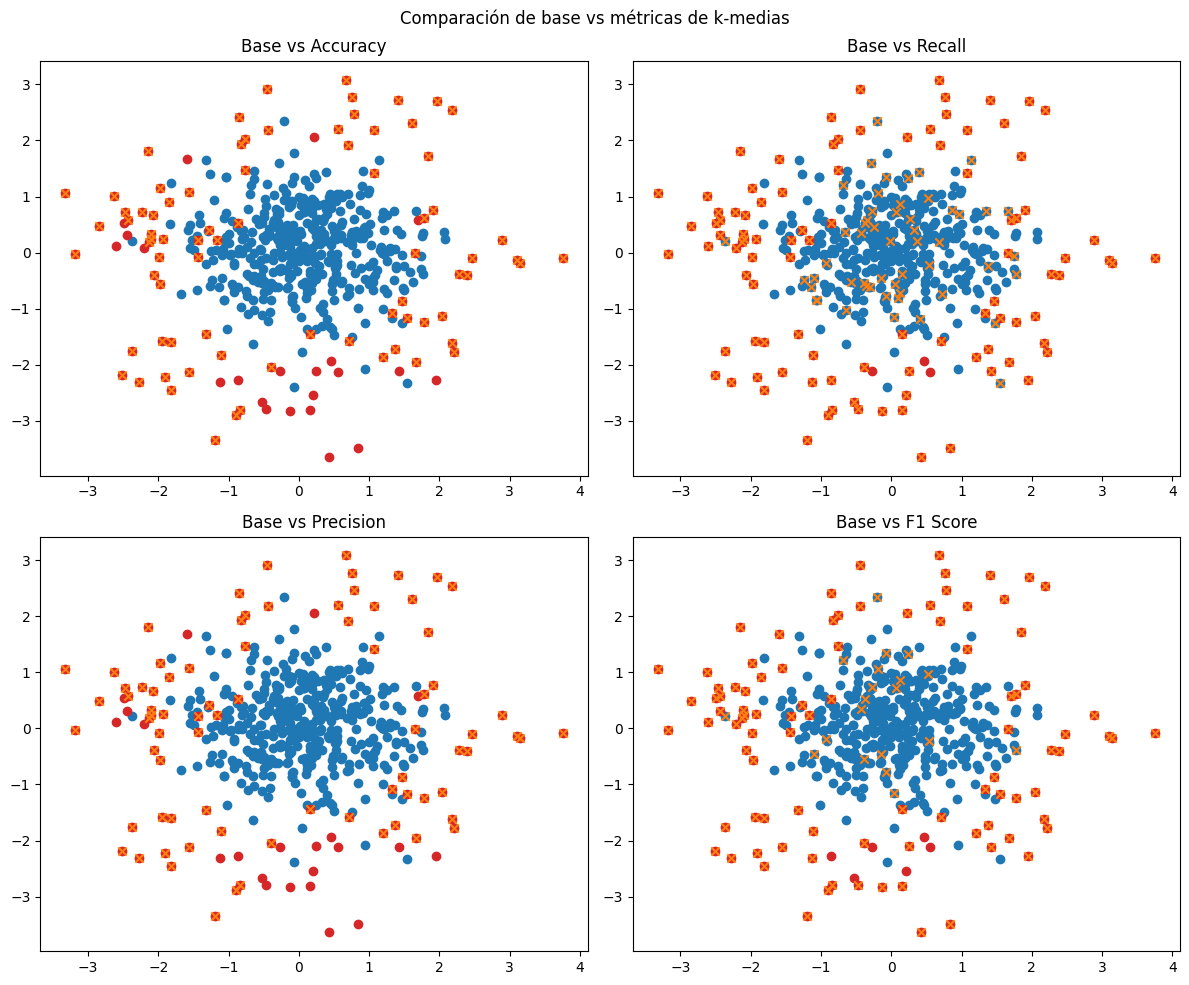

In [ ]:
import matplotlib.pyplot as plt

model = 'k-medias'
df_kmeans, y, outliers_results = algoritmo(df)
graficos(model, pca, y, outliers_results)


In [ ]:
df_kmeans

,Metric,Best Score,Best n_neighbors,Best Metric,Best Contamination,Number of Outliers
0,accuracy,0.956000,3,k-means++,84.50,78
1,recall,0.970000,3,k-means++,70.00,150
2,precision,1.000000,3,k-means++,84.50,78
3,f1,0.878505,3,k-means++,77.25,114


--- k-medias_accuracy ---
              precision    recall  f1-score   support

       Falso       0.95      1.00      0.97       400
   Verdadero       1.00      0.78      0.88       100

    accuracy                           0.96       500
   macro avg       0.97      0.89      0.92       500
weighted avg       0.96      0.96      0.95       500

--- k-medias_recall ---
              precision    recall  f1-score   support

       Falso       0.99      0.87      0.93       400
   Verdadero       0.65      0.97      0.78       100

    accuracy                           0.89       500
   macro avg       0.82      0.92      0.85       500
weighted avg       0.92      0.89      0.90       500

--- k-medias_precision ---
              precision    recall  f1-score   support

       Falso       0.95      1.00      0.97       400
   Verdadero       1.00      0.78      0.88       100

    accuracy                           0.96       500
   macro avg       0.97      0.89      0.92       5

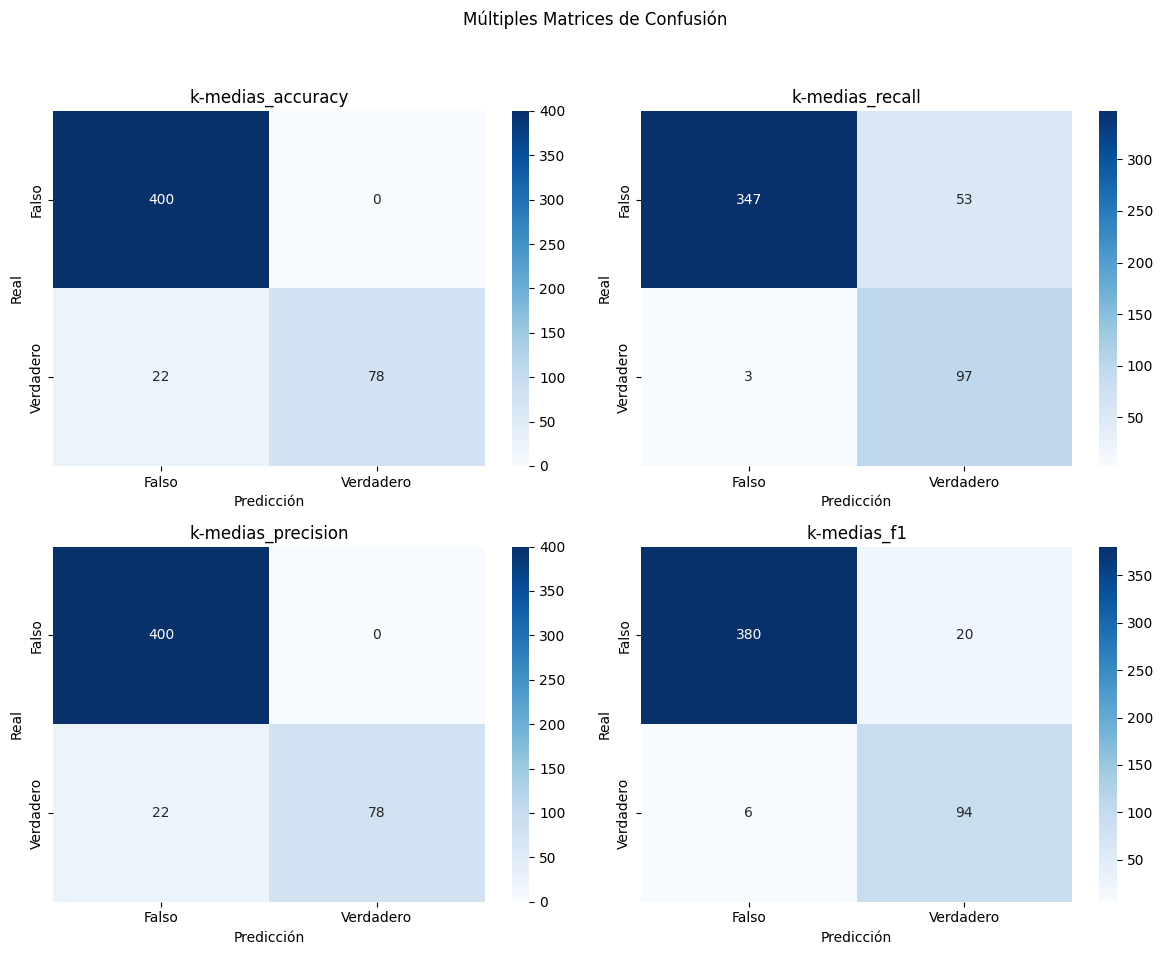

In [ ]:
plot_multiple_confusion_matrices(
    y_trues_preds=[
        (y, outliers_results[f"{model}_accuracy"]),
        (y, outliers_results[f"{model}_recall"]),
        (y, outliers_results[f"{model}_precision"]),
        (y, outliers_results[f"{model}_f1"])
    ],
    titles=[
        f"{model}_accuracy",
        f"{model}_recall",
        f"{model}_precision",
        f"{model}_f1"
    ]
)

#Tratamiento

In [ ]:
result = outliers_results[f"{model}_f1"]

##Dejar los outliers

In [ ]:
df_completo = df.copy()
df_completo = df_completo.drop_duplicates()

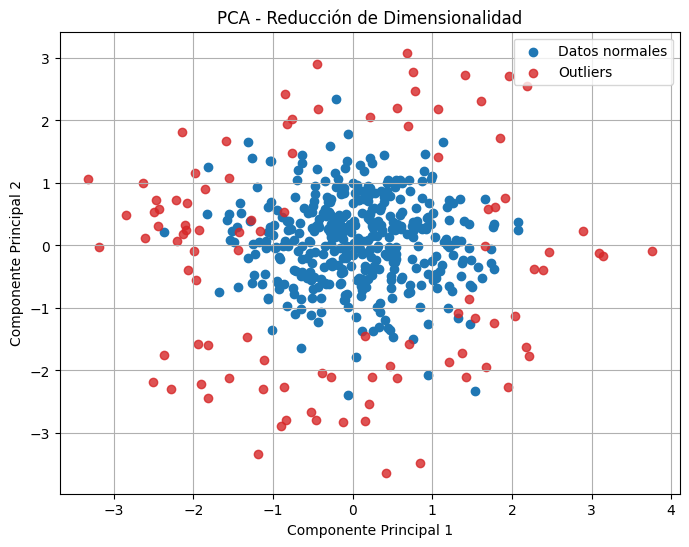

In [ ]:
df_iso_completo, y, outliers_results = algoritmo(df_completo)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df_completo.drop(columns=['is_outlier']), df_completo['is_outlier'])

plt.show()

In [ ]:
df_iso_completo

,Metric,Best Score,Best n_neighbors,Best Metric,Best Contamination,Number of Outliers
0,accuracy,0.956000,3,k-means++,84.50,78
1,recall,0.970000,3,k-means++,70.00,150
2,precision,1.000000,3,k-means++,84.50,78
3,f1,0.878505,3,k-means++,77.25,114


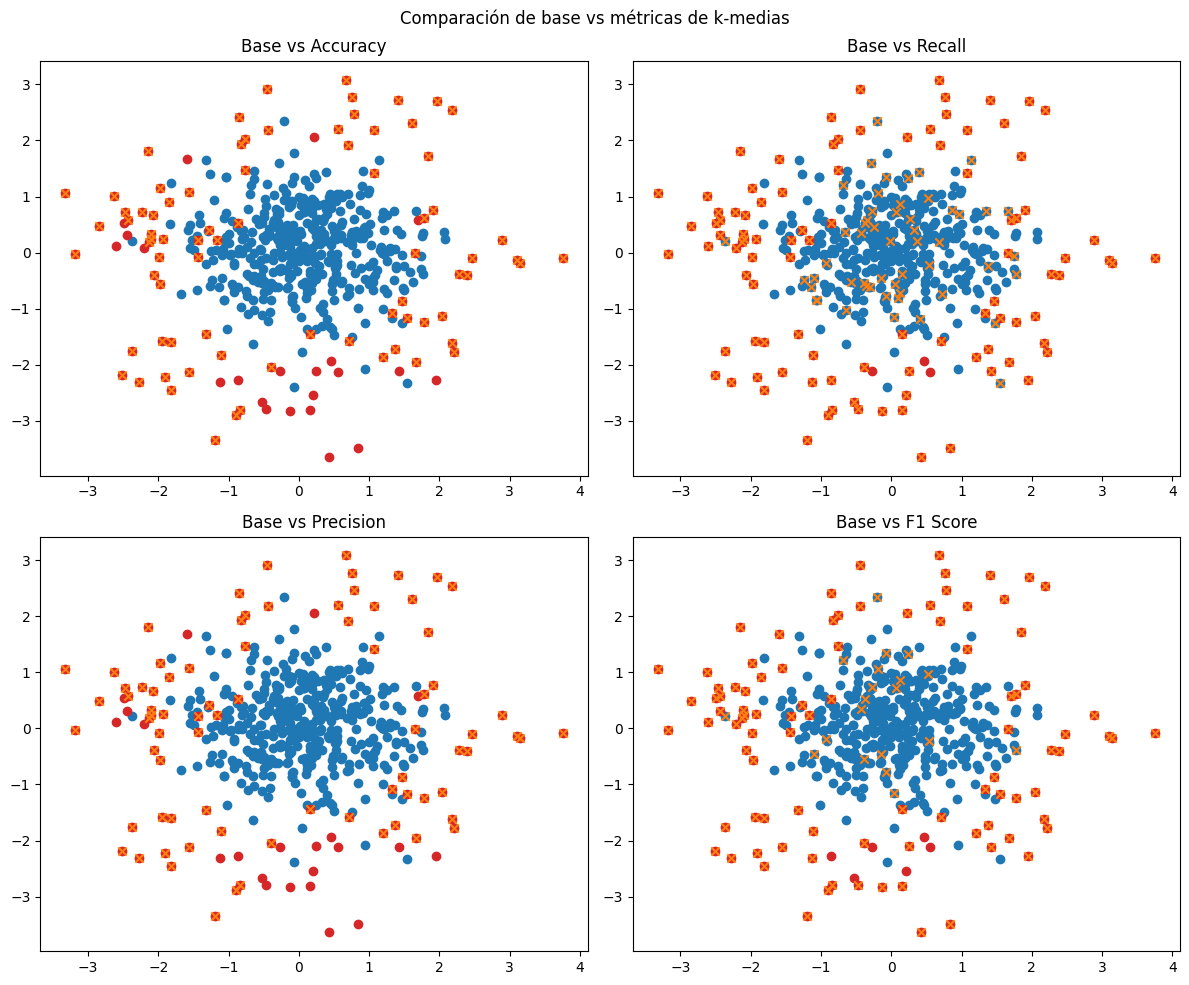

In [ ]:
graficos(model, pca, y, outliers_results)

##Eliminar los outliers

In [ ]:
df_eliminados = df[~result].copy()
df_eliminados = df_eliminados.drop_duplicates()

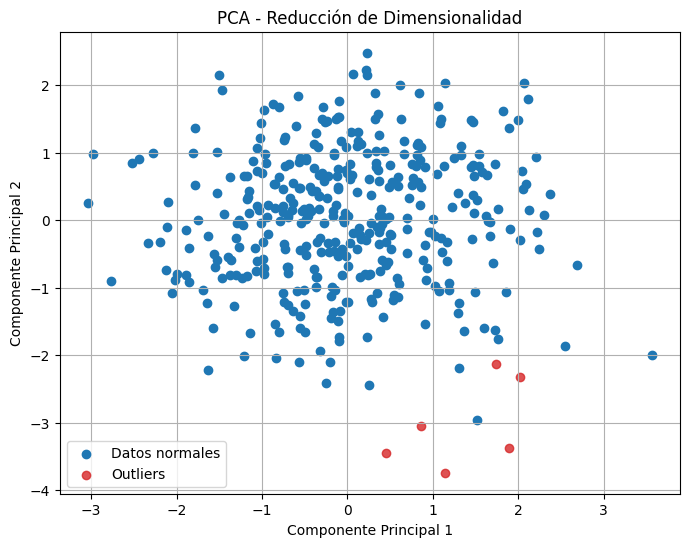

In [ ]:
df_iso_eliminados, y, outliers_results = algoritmo(df_eliminados)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df_eliminados.drop(columns=['is_outlier']), df_eliminados['is_outlier'])

plt.show()

In [ ]:
df_iso_eliminados

,Metric,Best Score,Best n_neighbors,Best Metric,Best Contamination,Number of Outliers
0,accuracy,0.994819,3,k-means++,99.0,4
1,recall,1.000000,3,k-means++,70.0,116
2,precision,1.000000,3,k-means++,99.0,4
3,f1,0.800000,3,k-means++,99.0,4


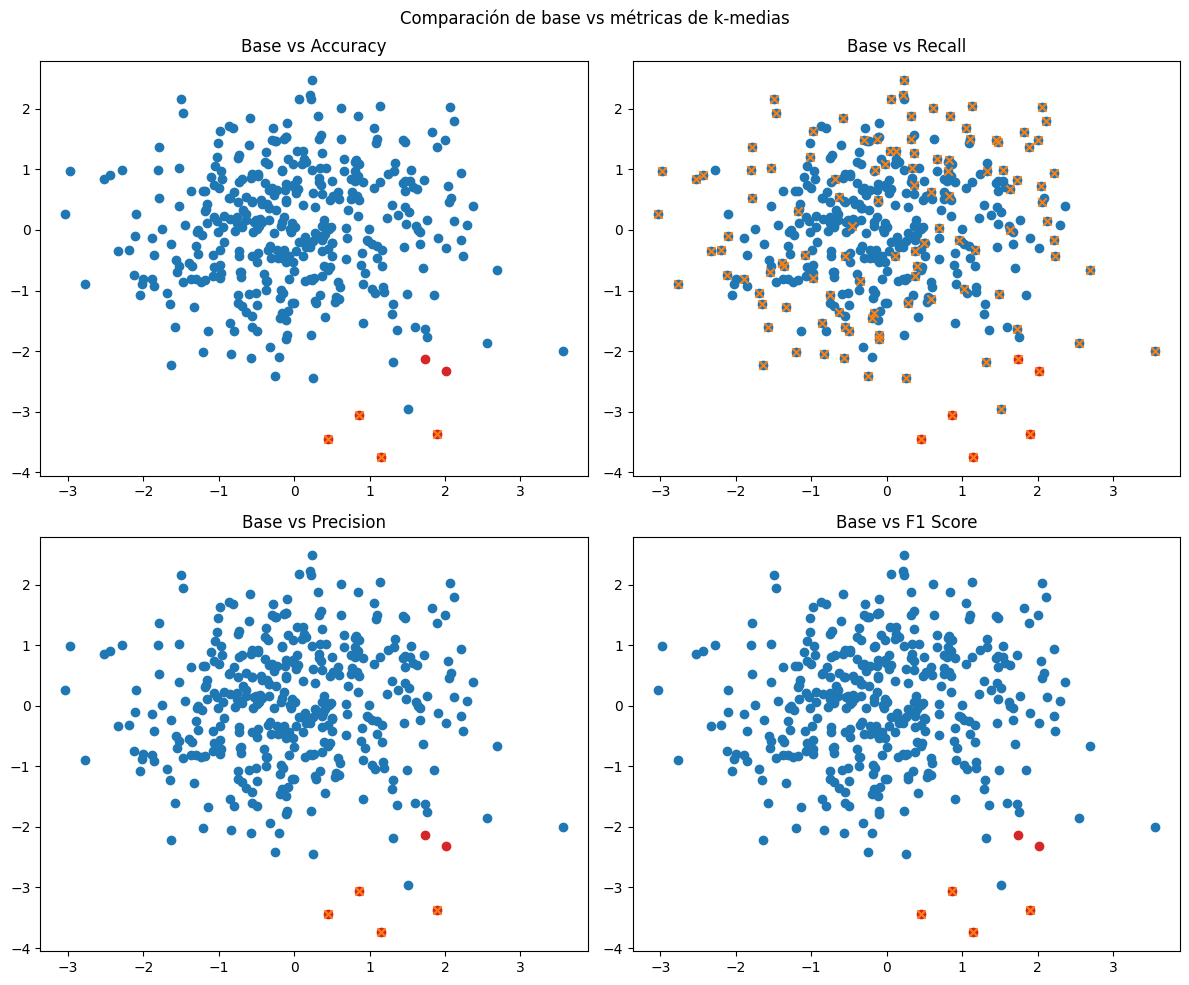

In [ ]:
graficos(model, pca, y, outliers_results)

--- k-medias_accuracy ---
              precision    recall  f1-score   support

       Falso       0.99      1.00      1.00       380
   Verdadero       1.00      0.67      0.80         6

    accuracy                           0.99       386
   macro avg       1.00      0.83      0.90       386
weighted avg       0.99      0.99      0.99       386

--- k-medias_recall ---
              precision    recall  f1-score   support

       Falso       1.00      0.71      0.83       380
   Verdadero       0.05      1.00      0.10         6

    accuracy                           0.72       386
   macro avg       0.53      0.86      0.46       386
weighted avg       0.99      0.72      0.82       386

--- k-medias_precision ---
              precision    recall  f1-score   support

       Falso       0.99      1.00      1.00       380
   Verdadero       1.00      0.67      0.80         6

    accuracy                           0.99       386
   macro avg       1.00      0.83      0.90       3

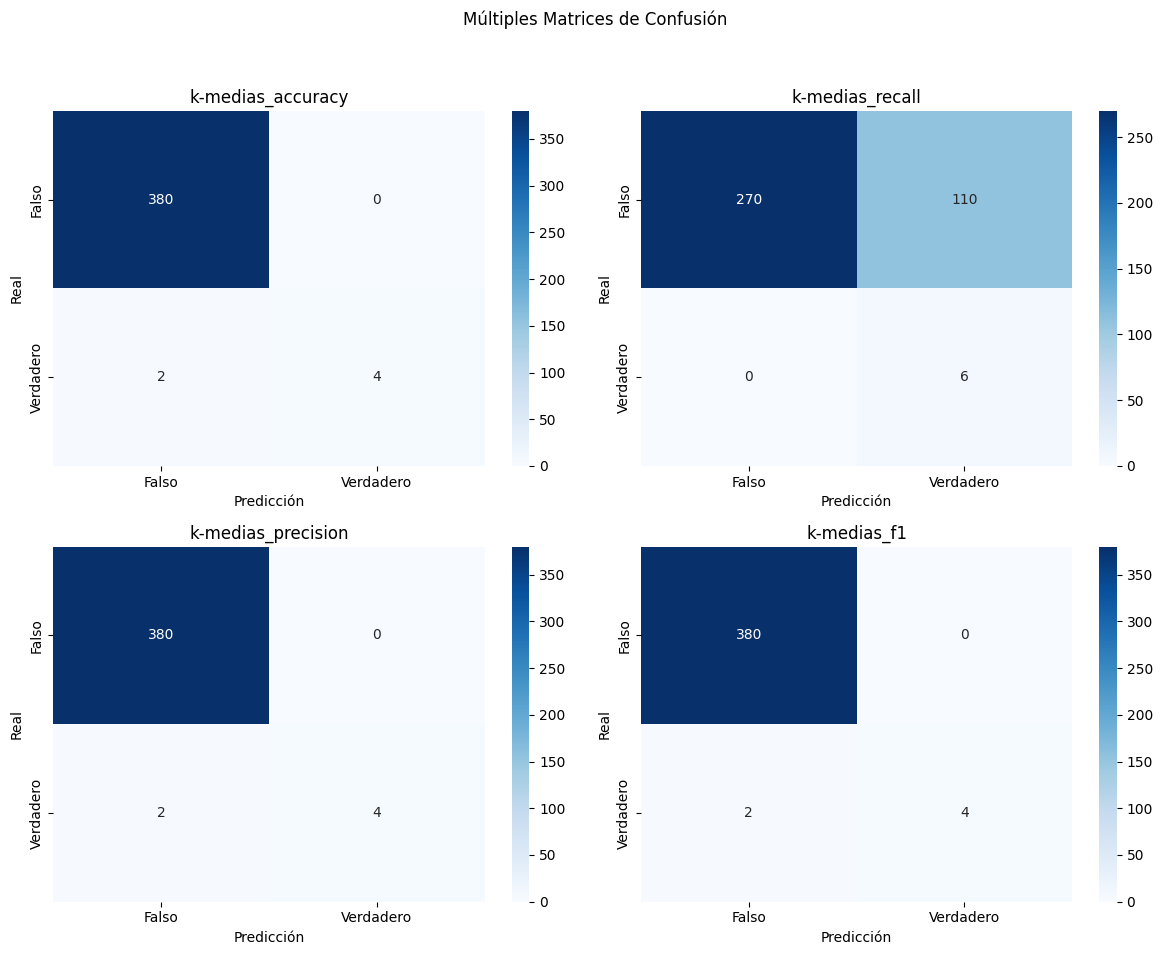

In [ ]:
plot_multiple_confusion_matrices(
    y_trues_preds=[
        (y, outliers_results[f"{model}_accuracy"]),
        (y, outliers_results[f"{model}_recall"]),
        (y, outliers_results[f"{model}_precision"]),
        (y, outliers_results[f"{model}_f1"])
    ],
    titles=[
        f"{model}_accuracy",
        f"{model}_recall",
        f"{model}_precision",
        f"{model}_f1"
    ]
)

##Cambiar por la media

In [ ]:
# Calcular la mediana de cada columna (solo inliers)
X_mean_aux = df.drop(columns=['is_outlier'])
median_values = np.median(X_mean_aux[~result], axis=0)  # ~outlier_mask = inliers

X_imputed = df.drop(columns=['is_outlier']).copy()
# Reemplazar outliers con la mediana
X_imputed[result] = median_values
df_imputed = pd.DataFrame(X_imputed, columns=X_mean_aux.columns)
df_imputed['is_outlier'] = df['is_outlier'].values  # Asegurar alineación por índice
df_imputed = df_imputed.drop_duplicates()

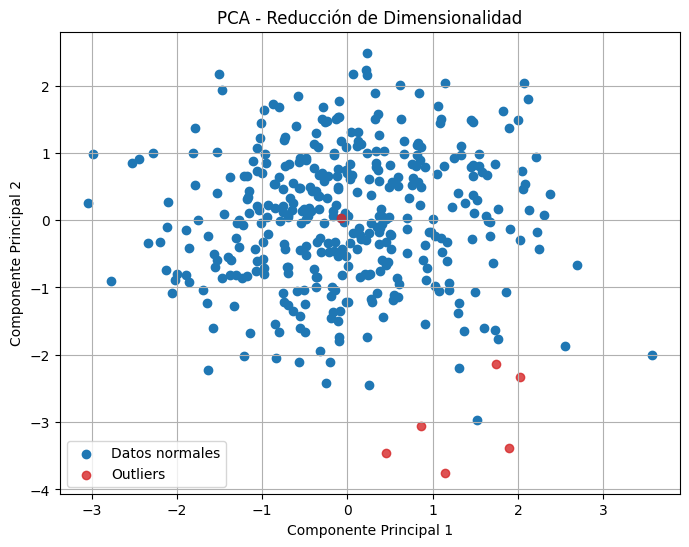

In [ ]:
df_iso_imputed, y, outliers_results = algoritmo(df_imputed)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df_imputed.drop(columns=['is_outlier']), df_imputed['is_outlier'])

plt.show()

In [ ]:
df_iso_imputed

,Metric,Best Score,Best n_neighbors,Best Metric,Best Contamination,Number of Outliers
0,accuracy,0.992268,3,k-means++,99.0,4
1,recall,0.857143,3,k-means++,70.0,117
2,precision,1.000000,3,k-means++,99.0,4
3,f1,0.727273,3,k-means++,99.0,4


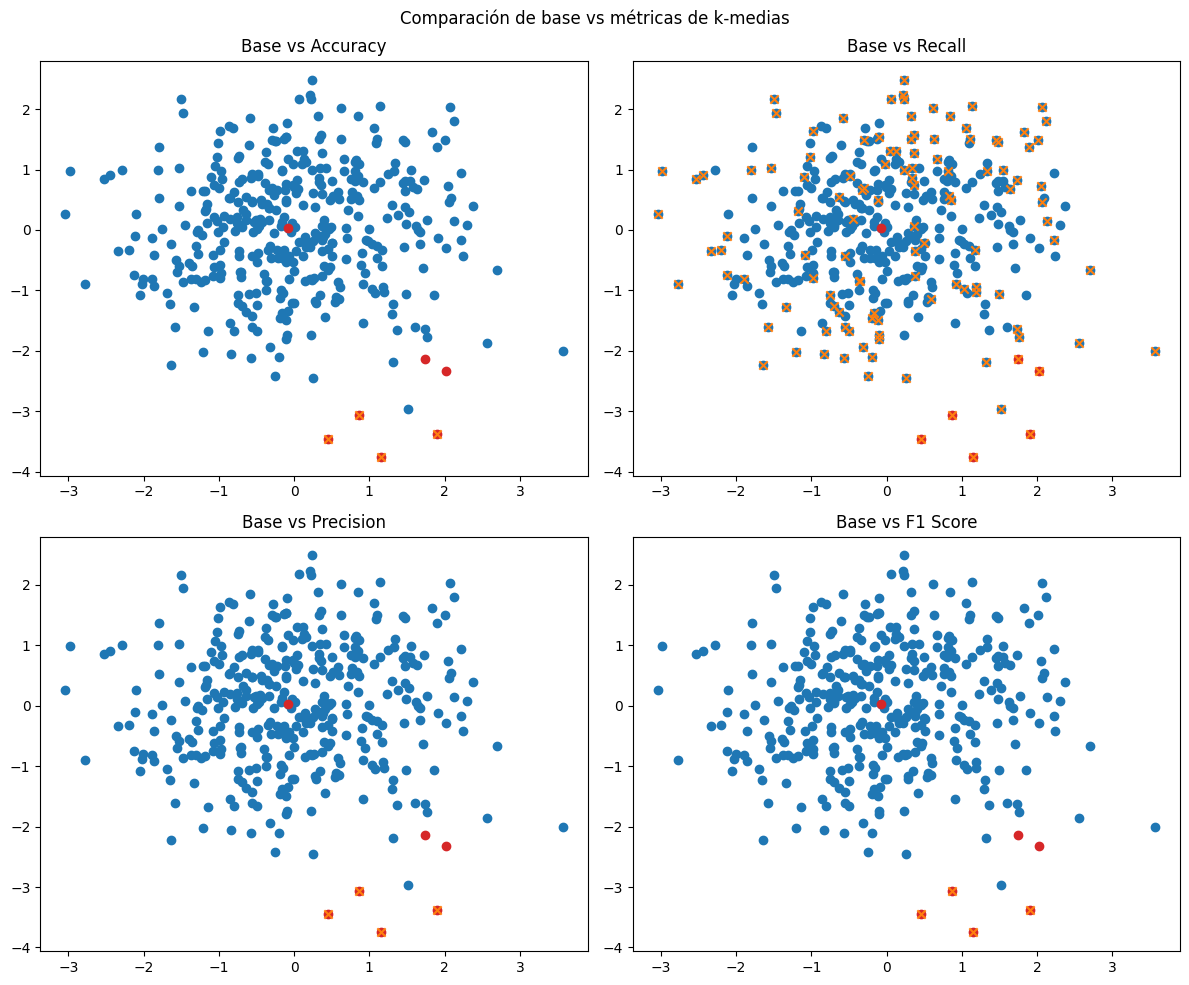

In [ ]:
graficos(model, pca, y, outliers_results)

--- k-medias_accuracy ---
              precision    recall  f1-score   support

       Falso       0.99      1.00      1.00       381
   Verdadero       1.00      0.57      0.73         7

    accuracy                           0.99       388
   macro avg       1.00      0.79      0.86       388
weighted avg       0.99      0.99      0.99       388

--- k-medias_recall ---
              precision    recall  f1-score   support

       Falso       1.00      0.71      0.83       381
   Verdadero       0.05      0.86      0.10         7

    accuracy                           0.71       388
   macro avg       0.52      0.78      0.46       388
weighted avg       0.98      0.71      0.82       388

--- k-medias_precision ---
              precision    recall  f1-score   support

       Falso       0.99      1.00      1.00       381
   Verdadero       1.00      0.57      0.73         7

    accuracy                           0.99       388
   macro avg       1.00      0.79      0.86       3

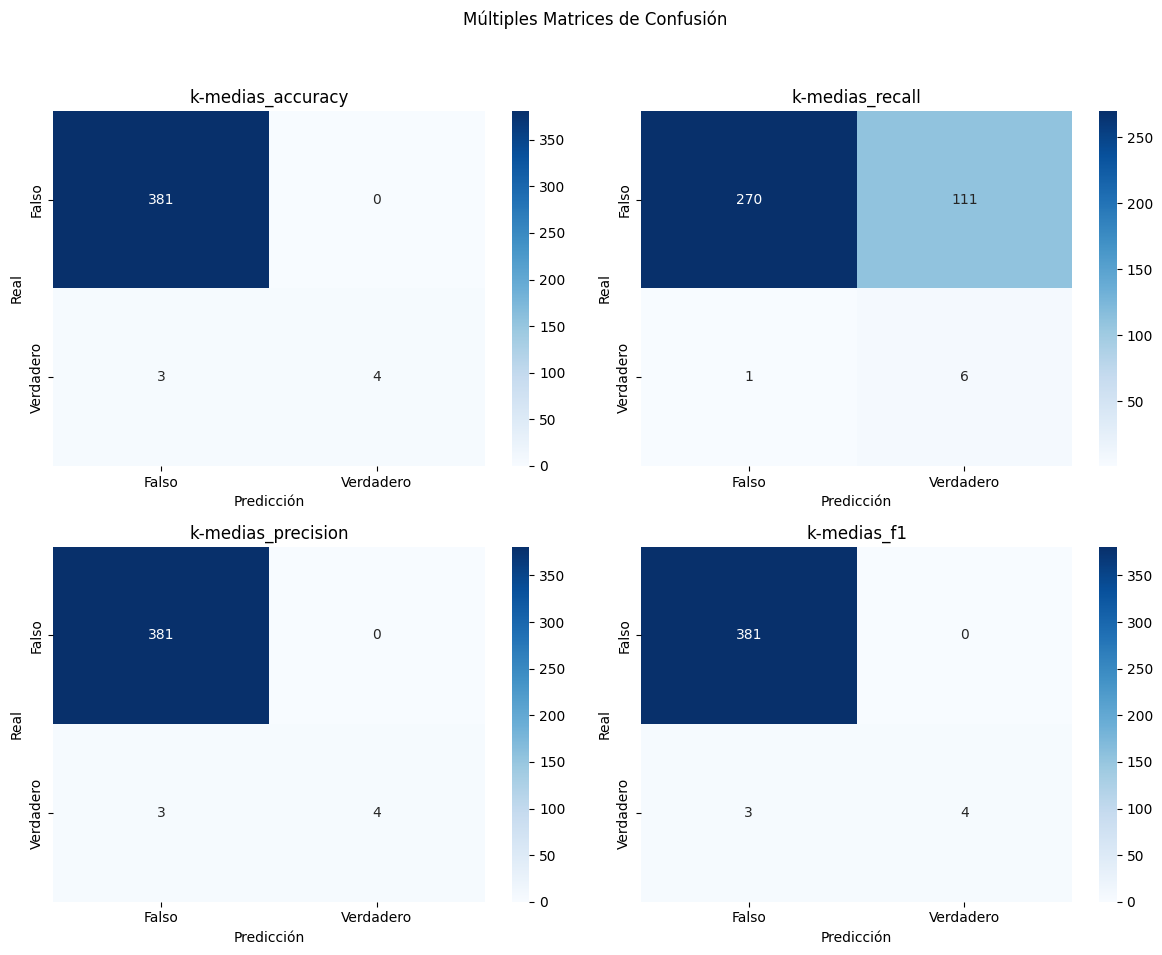

In [ ]:
plot_multiple_confusion_matrices(
    y_trues_preds=[
        (y, outliers_results[f"{model}_accuracy"]),
        (y, outliers_results[f"{model}_recall"]),
        (y, outliers_results[f"{model}_precision"]),
        (y, outliers_results[f"{model}_f1"])
    ],
    titles=[
        f"{model}_accuracy",
        f"{model}_recall",
        f"{model}_precision",
        f"{model}_f1"
    ]
)

##Winsorización

In [ ]:
# Porcentaje a recortar por ambos extremos (por ejemplo, 1%)
lower_pct = 0.05
upper_pct = 0.95

X_win_aux = df.drop(columns=['is_outlier'])
# Crear copia para winsorizar
X_winsorized = X_win_aux.copy()

# Aplicar winsorización por columnas
for col in X_win_aux.columns:
    lower_bound = X_win_aux[col].quantile(lower_pct)
    upper_bound = X_win_aux[col].quantile(upper_pct)
    X_winsorized[col] = X_win_aux[col].clip(lower=lower_bound, upper=upper_bound)

# Crear DataFrame final con la columna 'is_outlier' original
df_winsorized = pd.DataFrame(X_winsorized, columns=X_win_aux.columns)
df_winsorized['is_outlier'] = df['is_outlier'].values  # Conservar etiquetas de outliers si ya las tenías
df_winsorized = df_winsorized.drop_duplicates()

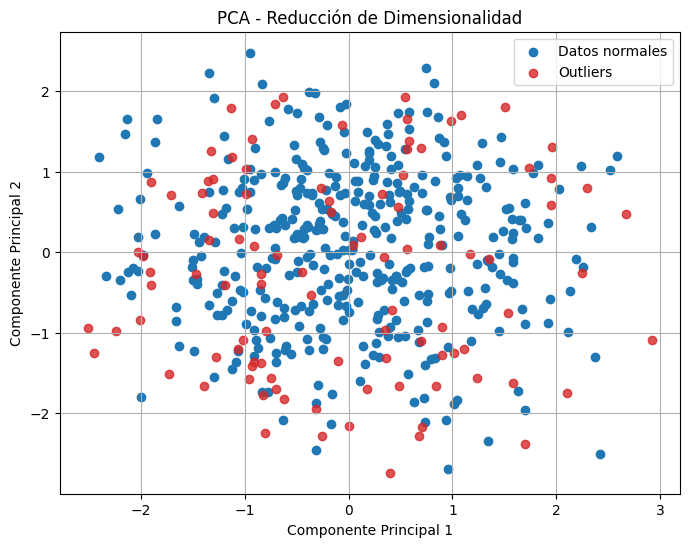

In [ ]:
df_iso_imputed, y, outliers_results = algoritmo(df_winsorized)
# Supongamos que df es el DataFrame con tus datos
fig, pca = pca_and_plot(df_winsorized.drop(columns=['is_outlier']), df_winsorized['is_outlier'])

plt.show()

In [ ]:
df_iso_imputed

,Metric,Best Score,Best n_neighbors,Best Metric,Best Contamination,Number of Outliers
0,accuracy,0.806000,10,k-means++,99.00,5
1,recall,0.520000,3,random,70.00,150
2,precision,0.800000,10,k-means++,99.00,5
3,f1,0.420561,10,random,77.25,114


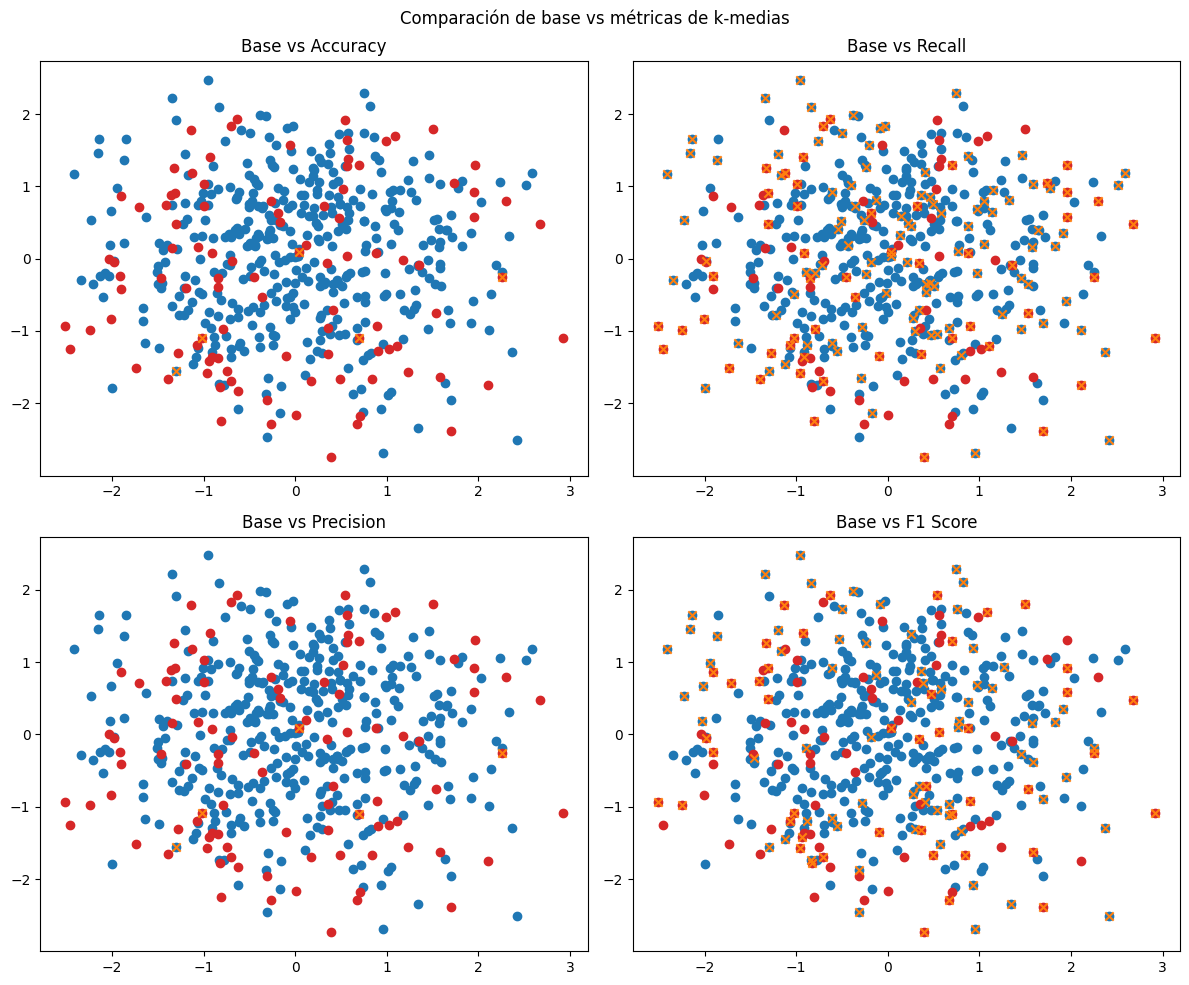

In [ ]:
graficos(model, pca, y, outliers_results)

--- k-medias_accuracy ---
              precision    recall  f1-score   support

       Falso       0.81      1.00      0.89       400
   Verdadero       0.80      0.04      0.08       100

    accuracy                           0.81       500
   macro avg       0.80      0.52      0.48       500
weighted avg       0.80      0.81      0.73       500

--- k-medias_recall ---
              precision    recall  f1-score   support

       Falso       0.86      0.76      0.81       400
   Verdadero       0.35      0.52      0.42       100

    accuracy                           0.71       500
   macro avg       0.60      0.64      0.61       500
weighted avg       0.76      0.71      0.73       500

--- k-medias_precision ---
              precision    recall  f1-score   support

       Falso       0.81      1.00      0.89       400
   Verdadero       0.80      0.04      0.08       100

    accuracy                           0.81       500
   macro avg       0.80      0.52      0.48       5

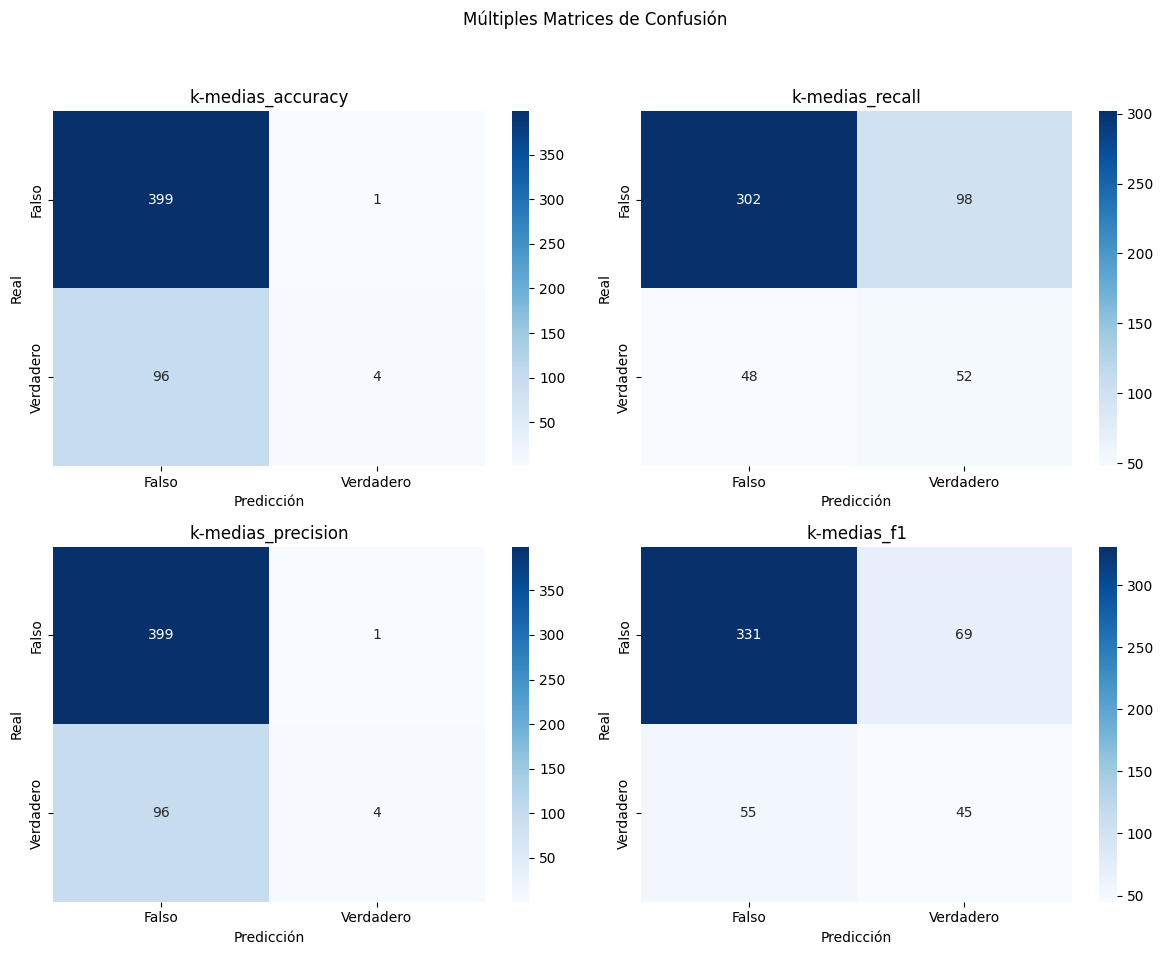

In [ ]:
plot_multiple_confusion_matrices(
    y_trues_preds=[
        (y, outliers_results[f"{model}_accuracy"]),
        (y, outliers_results[f"{model}_recall"]),
        (y, outliers_results[f"{model}_precision"]),
        (y, outliers_results[f"{model}_f1"])
    ],
    titles=[
        f"{model}_accuracy",
        f"{model}_recall",
        f"{model}_precision",
        f"{model}_f1"
    ]
)